# Business Problem
Effective inventory and sales management are critical for optimizing profitability in reatil and wholesale industry. Companies need to ensure that they are not incurring losses due to ineffcient pricing, poor inventory turover, or vendor dependency. The goal of this analysis is to:
1. Identify underperforming brands that require promotional or pricing adjustments.
2. Determine top vendors contributing to sales and gross profit
3. Analyze the impact of bulk purchasing on unit costs.
4. Assess inventory turnover to reduce holding costs and improve efficiency.
5. Investigate the profitability variance between high-performing and low-performing vendors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('inventory.db')
df = pd.read_sql_query('select * from vendor_sales_summary',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis 
* Previously we examined the various tables in the database to identify key variables, understand their realtionships and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyse the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.00,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,18054.503193,12643.196784,58.00,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,24.402095,109.483355,0.36,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10648.0,35.671184,148.534066,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10648.0,847.883875,665.354152,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10648.0,3145.159936,11113.367455,1.00,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,30138.163064,123277.154715,0.71,452.857500,3646.725000,20764.170000,3.811252e+06
TotalSalesQuantity,10648.0,3081.902047,10971.073340,0.00,33.000000,260.500000,1934.250000,3.349390e+05
TotalSalesDollars,10648.0,42302.921643,167947.264974,0.00,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,18813.647626,45018.406384,0.00,288.830000,2841.775000,16080.270000,6.728193e+05


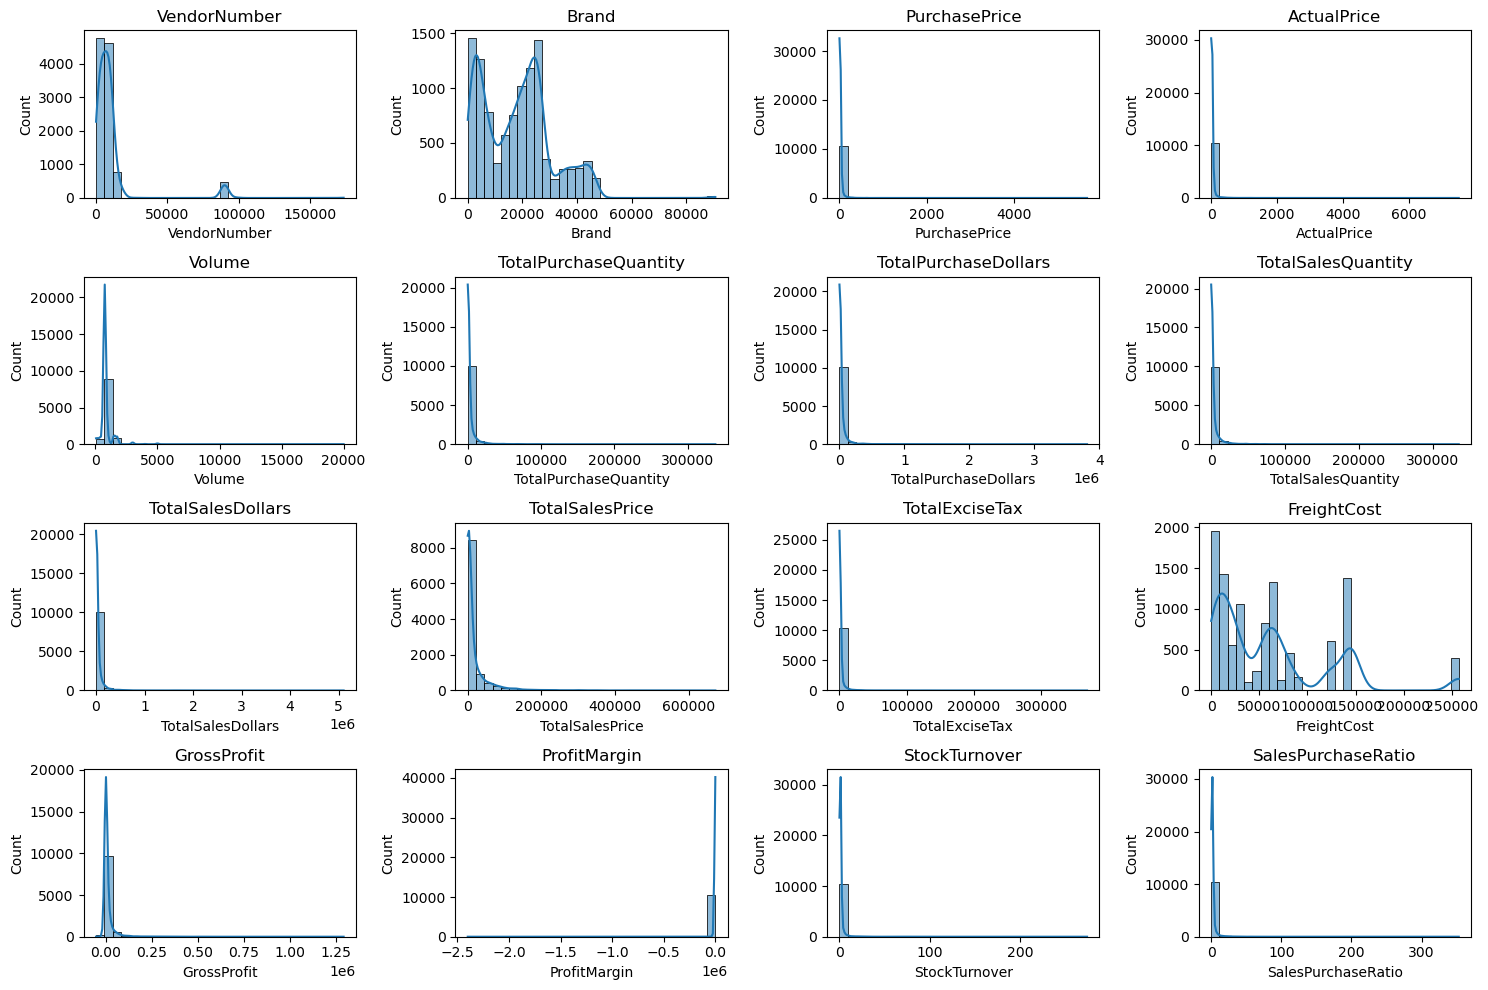

In [4]:
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)

plt.tight_layout()
plt.show()

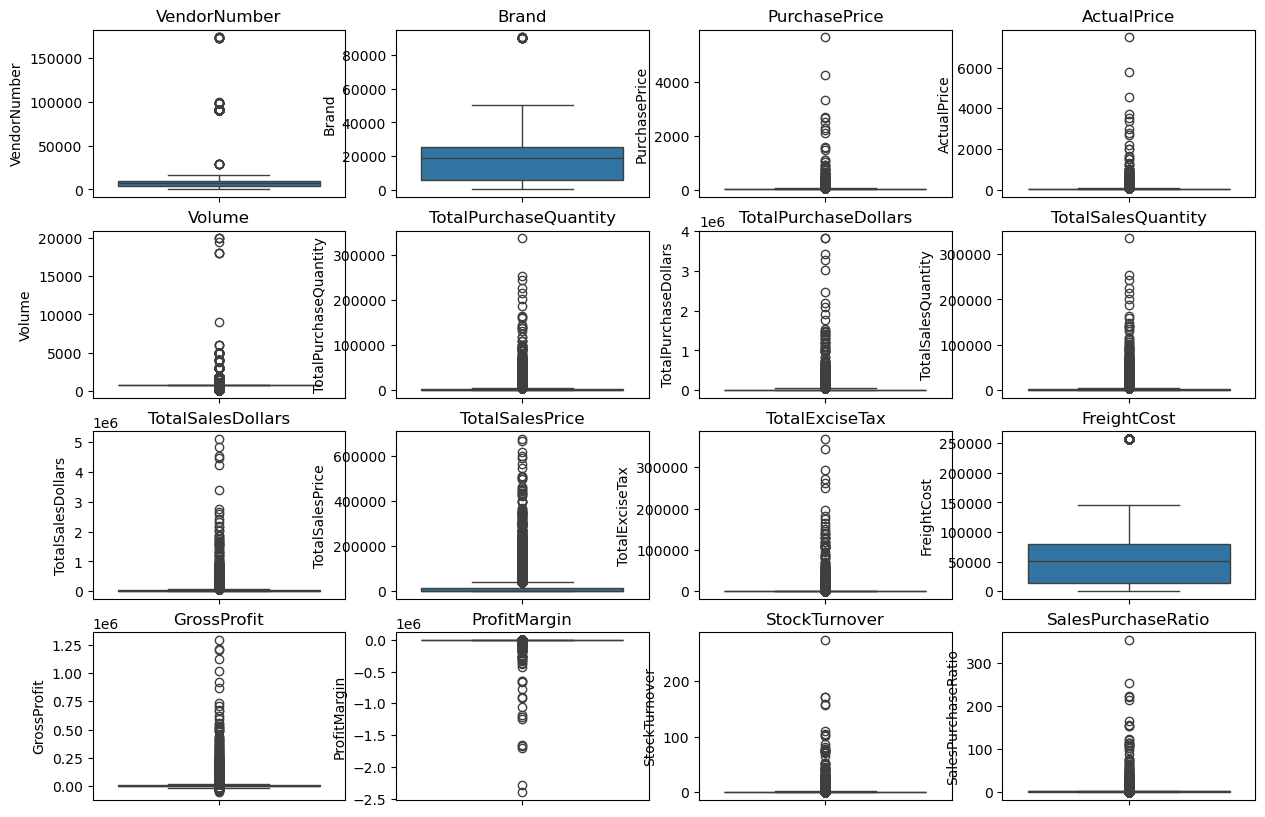

In [5]:
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout
plt.show()

# Summary Statistics Insights
Negative & Zero Values:
* Gross profit: Minimum value is -52002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Revenue is zero or lower than costs
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:
* Purchase & Actual Prices: The max values (5.681.81 & 7,499.99) are significantly higher than mean(24.39 & 35.64), indicating potential premimum products.
* Freight Cost: Huge variation, from 0.27 to 257032.1, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [6]:
df = pd.read_sql_query('''select * from vendor_sales_summary 
                       where GrossProfit > 0 and ProfitMargin > 0
                       and TotalSalesQuantity > 0''', conn)

In [7]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8536,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8537,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8538,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8539,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


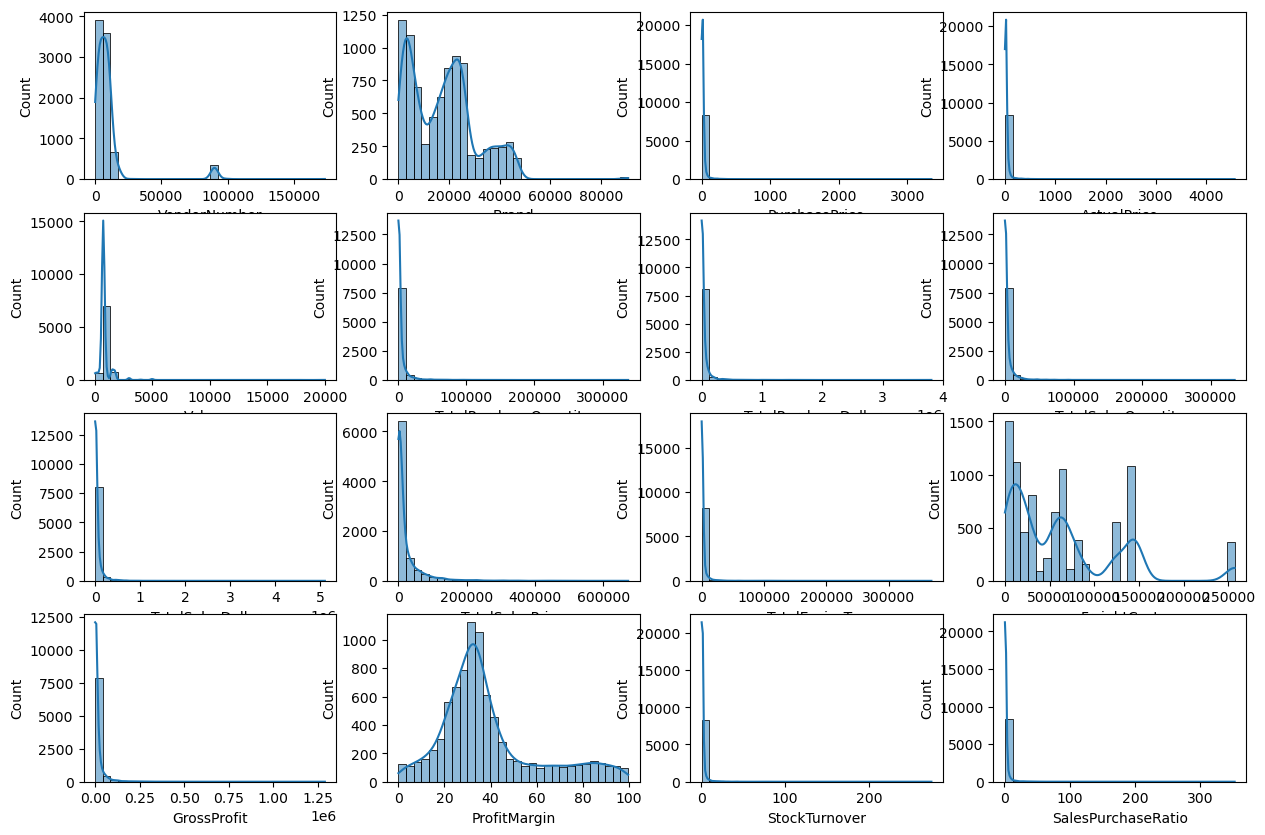

In [8]:
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde = True, bins = 30)
plt.show()

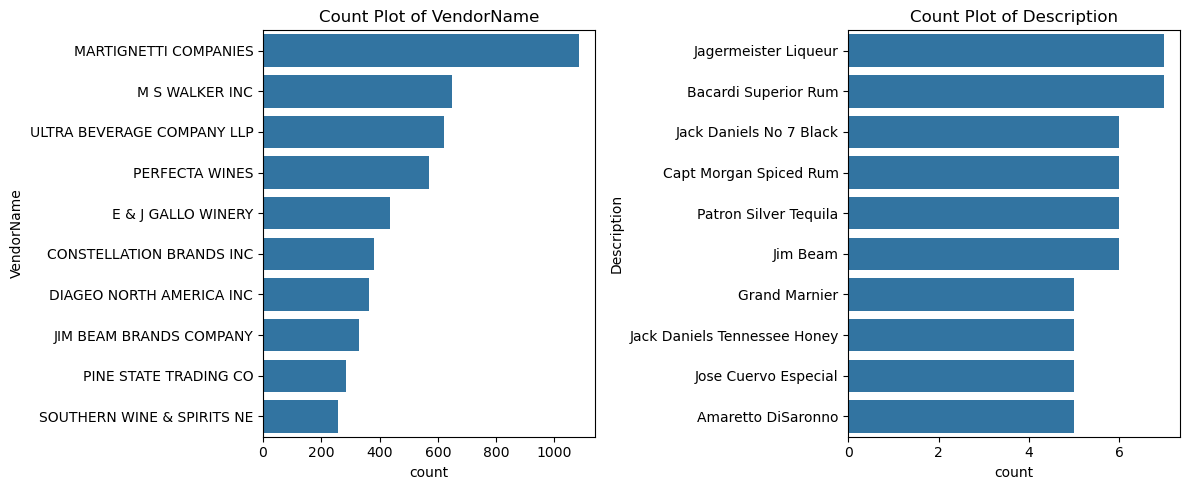

In [9]:
categorical_cols = ['VendorName','Description'] 

plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y = df[col], order = df[col].value_counts().index[:10])
    plt.title(f'Count Plot of {col}')
plt.tight_layout()
plt.show()

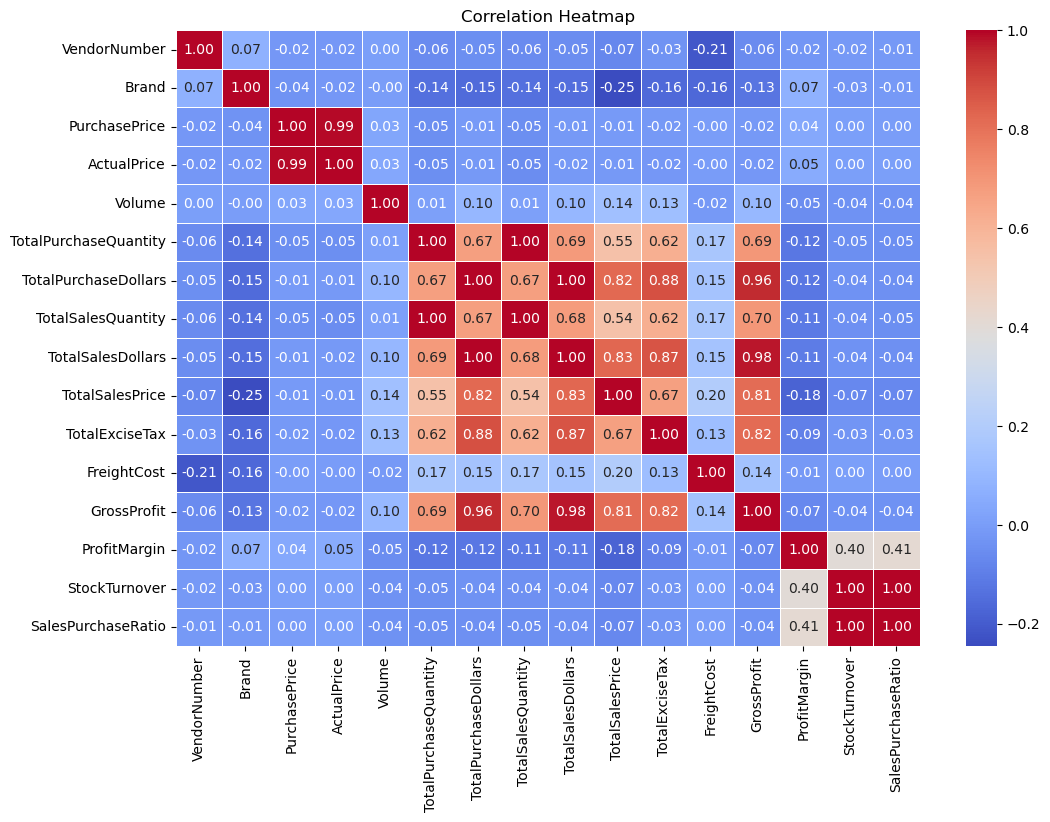

In [10]:
plt.figure(figsize = (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(data = correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidth = 0.5)
plt.title('Correlation Heatmap')
plt.show()

# Correlation Insights 
* PurchasePrice has weak correaltion with TotalSalesDollars (-0.01) and GrossProfit (-0.02), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and tatal sales quantity (1) confirming efficient inventory turnover.
* Negative correaltion between profit margin and total sales price (-0.18) suggests that sales price increases, margin decreases, possibly due to competitive pricing pressures.
* Stock turnover has weak negative correaltions with both gross profit (-0.04) and profit margin (0.40) indicating that faster turnover does not result in higher profitability. 

# Data Analysis 
Q1) Identify brands that need promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.

In [11]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesPurchaseRatio'],
      dtype='object')

In [12]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [13]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7700,Zorvino Vyds Sangiovese,10579.03,29.525675
7701,Zuccardi Q Malbec,1639.18,23.981503
7702,Zum Rsl,10857.34,32.675038
7703,Zwack Liqueur,227.88,16.653502


In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
print('Low sales threshold:', low_sales_threshold )

Low sales threshold: 560.146


In [16]:
print('High margin threshold:', high_margin_threshold)

High margin threshold: 64.9299097086893


In [17]:
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & (brand_performance['ProfitMargin'] >= high_margin_threshold)]

In [18]:
print('Brands with low sales but high profit margin:')
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margin:


,Description,TotalSalesDollars,ProfitMargin
6197,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6235,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5072,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6243,Sbragia Home Ranch Merlot,549.75,66.444748


In [19]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000]

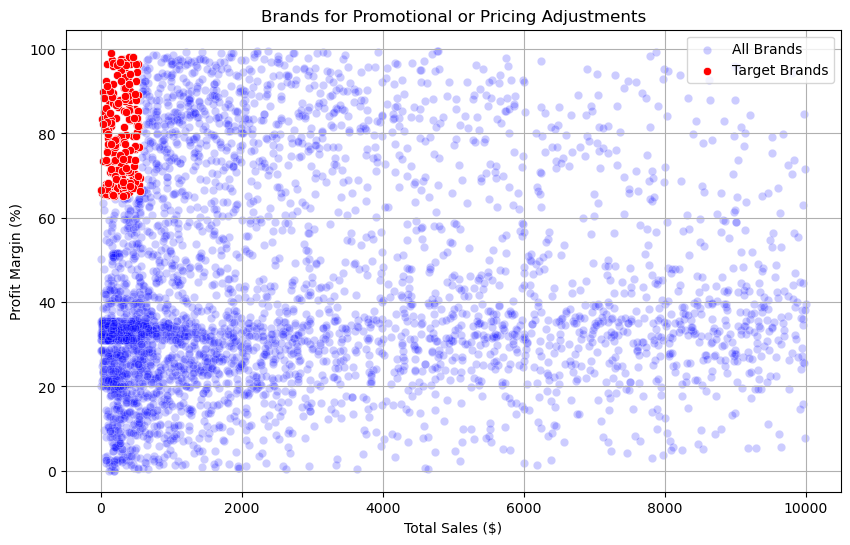

In [20]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollars' , y = 'ProfitMargin', color = 'blue', label = 'All Brands', alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars', y = 'ProfitMargin', color = 'red', label = 'Target Brands')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()

Q2) which vendor and brands demonstrate the highest sales performance?

In [21]:
def format_dollars(value):
    if isinstance(value, str):
        return value  

    if value >= 100000:
        return f'{value / 1_000_000:.2f}M'
    elif value >= 1000:
        return f'{value / 1_000:.2f}K'
    else:
        return str(value)

In [22]:
top_vendors_num = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands_num = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

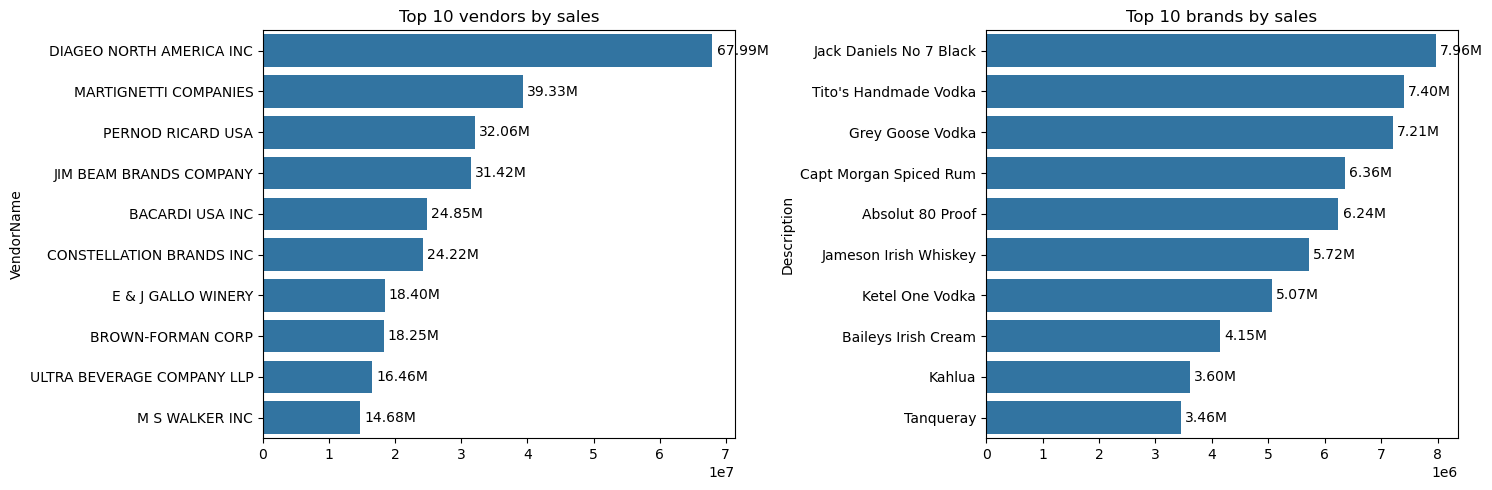

In [27]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors_num.index, x=top_vendors_num.values)
ax1.bar_label(
    ax1.containers[0],
    labels=[format_dollars(v) for v in top_vendors_num.values],
    padding=3
)
plt.title('Top 10 vendors by sales')

plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands_num.index, x=top_brands_num.values)
ax2.bar_label(
    ax2.containers[0],
    labels=[format_dollars(v) for v in top_brands_num.values],
    padding=3
)
plt.title('Top 10 brands by sales')

plt.tight_layout()
plt.show()

Q3) Which Vendor contribute to the most to total purchase dollars? 

In [33]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

In [42]:
vendor_performance.shape

(118, 5)

In [34]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
113,WEIN BAUER INC,42694.64,13522.49,56217.13
114,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
115,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
116,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [50]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [51]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [52]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.34
56,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.32
67,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.78
45,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.66
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.69
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.98
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.32
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.94
105,ULTRA BEVERAGE COMPANY LLP,11.13M,5.33M,16.46M,3.63
52,M S WALKER INC,9.75M,4.93M,14.68M,3.18


In [53]:
print(top_vendors['PurchaseContribution%'].sum())

65.84


In [54]:
top_vendors['Cumlative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

In [55]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumlative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.34,16.34
56,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.32,24.66
67,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.78,32.44
45,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.66,40.10
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.69,45.79
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.98,50.77
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.32,55.09
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.94,59.03
105,ULTRA BEVERAGE COMPANY LLP,11.13M,5.33M,16.46M,3.63,62.66
52,M S WALKER INC,9.75M,4.93M,14.68M,3.18,65.84


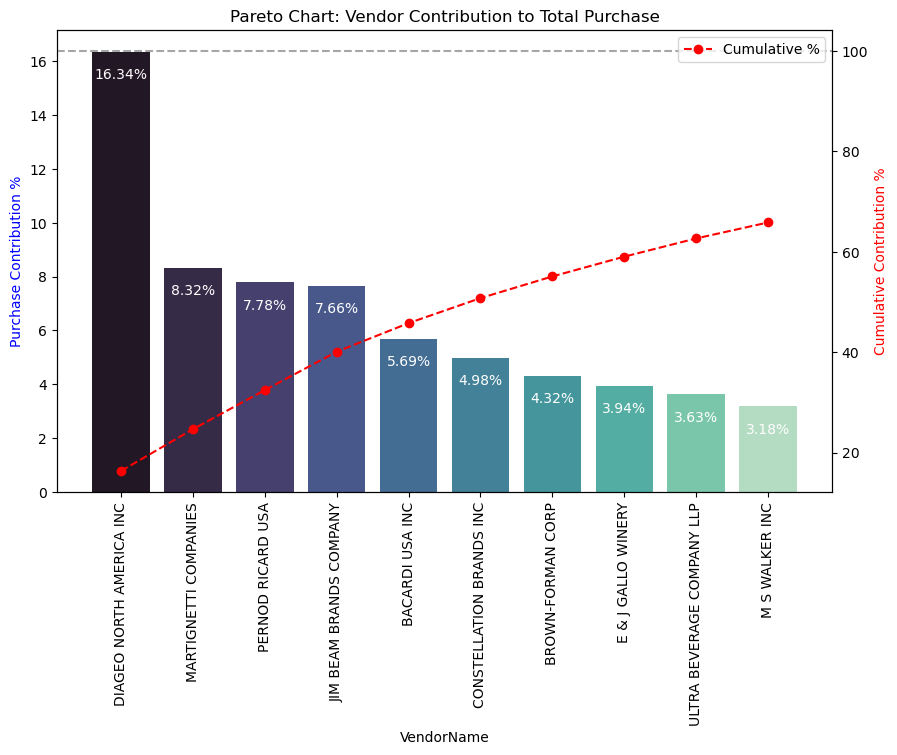

In [61]:
fig, ax1 = plt.subplots(figsize = (10,6))

sns.barplot( x = top_vendors['VendorName'], y = top_vendors['PurchaseContribution%'], palette = 'mako', ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value -1, str(value) + '%', ha = 'center', fontsize = 10, color = 'white')

ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumlative_Contribution%'], color = 'red', marker = 'o', linestyle = 'dashed', label = 'Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation = 90)
ax1.set_ylabel('Purchase Contribution %', color = 'blue')
ax2.set_ylabel('Cumulative Contribution %', color = 'red')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchase')

ax2.axhline(y = 100, color = 'gray', linestyle = 'dashed', alpha = 0.7)
ax2.legend(loc = 'upper right')

plt.show()

Q4) How much of total procurement is dependent on the top vendors?

In [62]:
print(f'Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%')

Total Purchase Contribution of top 10 vendors is 65.84%


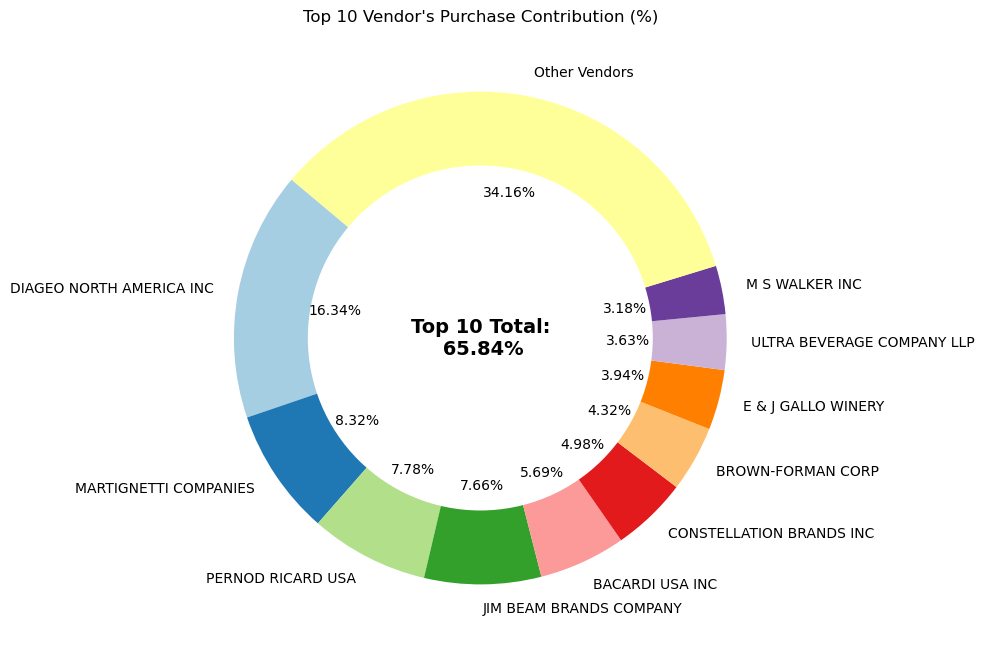

In [85]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contributions = 100 - total_contribution

vendors.append('Other Vendors')
purchase_contributions.append(remaining_contributions)

fig,ax = plt.subplots(figsize = (8,8))
ax.pie(purchase_contributions, labels = vendors, autopct = '%2.2f%%', startangle = 140, pctdistance = 0.6, colors = plt.cm.Paired.colors)

centre_circle = plt.Circle((0,0), 0.70, fc = 'white')
fig.gca().add_artist(centre_circle)

plt.text(0,0, f'Top 10 Total:\n{total_contribution : .2f}%', fontsize = 14, fontweight = 'bold', ha = 'center', va = 'center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Q5) Does the purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [86]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [87]:
df.head(4)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17


In [88]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels = ['Small','Medium','Large'])

In [90]:
df[['OrderSize','TotalPurchaseQuantity']] 

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8536,Small,2
8537,Small,6
8538,Small,2
8539,Small,1


In [91]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.128653
Medium,15.489374
Large,10.776200


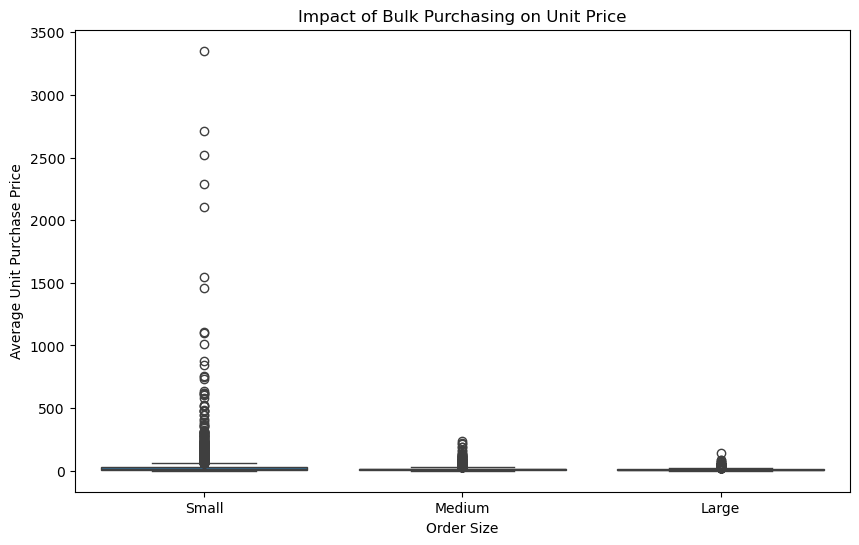

In [94]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'OrderSize', y = 'UnitPurchasePrice')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between small and large orders is substantial(~ 72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volume, leading to higher overall sales despite lower per-unit revenue. 

Q6) Which vendors have low inventory turnover, indicating excess stock and slow moving products?

In [98]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover' , ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


Q7) How much capital is locked in unsold inventory per vendor and which vendors contribute the most to it. 

In [101]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['PurchasePrice']
print('Total Unsold Capital:' , format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 2.69M


Aggregate Captial locked per vendor

In [104]:
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index() 

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = 'UnsoldInventoryValue' , ascending = False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,0.72M
45,JIM BEAM BRANDS COMPANY,0.55M
67,PERNOD RICARD USA,0.47M
115,WILLIAM GRANT & SONS INC,0.40M
30,E & J GALLO WINERY,0.23M
...,...,...
87,SOUTHERN WINE & SPIRITS NE,-71058.27
52,M S WALKER INC,-104338.89
56,MARTIGNETTI COMPANIES,-112538.34
105,ULTRA BEVERAGE COMPANY LLP,-190388.19


Q8) What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors

In [105]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [106]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [107]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3509    79.684817
3667    85.782102
4736    93.085860
4905    95.012530
5035    94.271857
Name: ProfitMargin, Length: 2136, dtype: float64

In [108]:
low_vendors

5615     4.111764
5636     6.145626
5685    12.007271
5688     1.677308
5708     7.239599
          ...    
8536    83.448276
8537    96.436186
8538    25.252525
8539    98.974037
8540    99.166079
Name: ProfitMargin, Length: 2136, dtype: float64

In [110]:
def confidence_interval(data, confidence = 0.95):
    mean_val = np.mean(data)
    std_error = np.std(data, ddof = 1) / np.sqrt(len(data)) 
    t_critical = stats.t.ppf((1 + confidence)/ 2, df = len(data) - 1)
    margin_of_error = t_critical * std_error
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: ( 30.73,  31.60), Mean: 31.17
Low Vendors 95% CI: ( 40.46,  42.60), Mean: 41.53


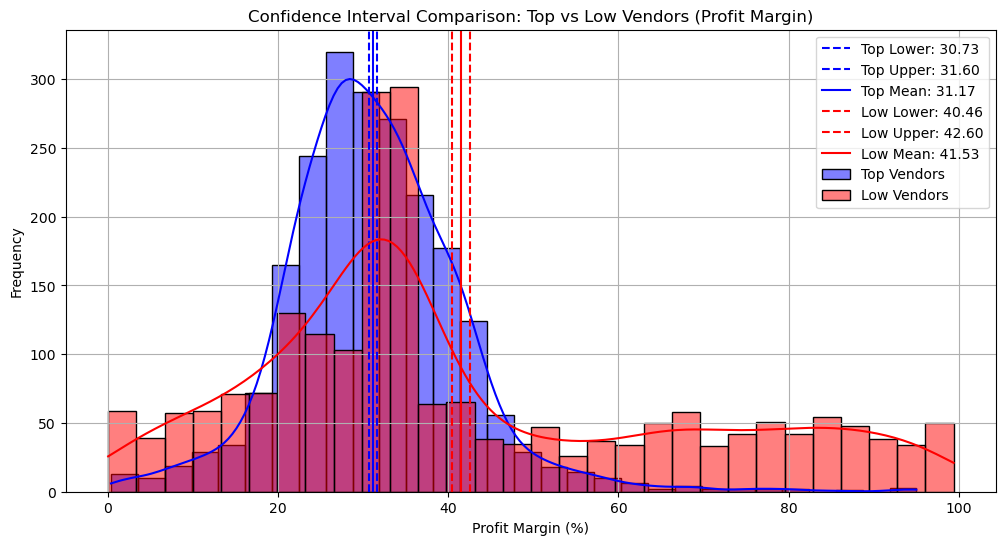

In [111]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f'Top Vendors 95% CI: ({top_lower: .2f}, {top_upper: .2f}), Mean: {top_mean:.2f}')
print(f'Low Vendors 95% CI: ({low_lower: .2f}, {low_upper: .2f}), Mean: {low_mean:.2f}')

plt.figure(figsize = (12,6))

sns.histplot(top_vendors, kde = True, color = 'blue', bins = 30, alpha = 0.5, label = 'Top Vendors')
plt.axvline(top_lower, color = 'blue', linestyle = '--', label= f'Top Lower: {top_lower:.2f}')
plt.axvline(top_upper, color = 'blue', linestyle = '--', label = f'Top Upper: {top_upper:.2f}')
plt.axvline(top_mean, color = 'blue', linestyle = '-', label = f'Top Mean: {top_mean:.2f}')

sns.histplot(low_vendors, kde = True, color = 'red', bins = 30, alpha = 0.5, label = 'Low Vendors')
plt.axvline(low_lower, color = 'red', linestyle = '--', label= f'Low Lower: {low_lower:.2f}')
plt.axvline(low_upper, color = 'red', linestyle = '--', label = f'Low Upper: {low_upper:.2f}')
plt.axvline(low_mean, color = 'red', linestyle = '-', label = f'Low Mean: {low_mean:.2f}')

plt.title('Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

* The confidence interval for low-performing vendors (40.46% to 42.60%) is significantly higher than that of top-performing vendors(30.73 to 31.60%)
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For high-performing vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundiling strategies.
* For low-performing vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

## Is there a significant difference in profit margins between top-performing and low-performing vendors?
Hypothesis: 

Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternate Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different. 

In [114]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var = False)

print(f'T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject Ho : There is significant difference in profit margins between top and low-performing vendors.')
else:
    print('Fail to Reject Ho : No significant difference in profit margin.')

T-Statistic: -17.6189, P-Value: 0.0000
Reject Ho : There is significant difference in profit margins between top and low-performing vendors.
